# Libraries and functions

In [1]:
"""Plot utilities for aggregated small-language-modeling NTP/RHM results.

This module works directly with the ``.npy`` dictionaries written by the
user's ``collect_file.py`` into ``collected_results/``.  It does not scan or
load the individual ``results.pt`` files.

Collected array conventions
---------------------------
* scalar seed-resolved curves:          [nP, nT, nSeeds]
* NTP curves resolved by position i:    [nP, nT, nSeeds, nPositions]
* RHM level curves:                     [nP, nT, nSeeds, L]
* RHM position-and-level curves:        [nP, nT, nSeeds, nPositions, L]

Position-resolved quantities are averaged over the position axis before they
are plotted, reproducing the convention of the earlier repository.
"""

from __future__ import annotations

from pathlib import Path
from typing import Any, Iterable
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


def load_collected_results(
    filename: str | Path,
    *,
    collected_results_dir: str | Path = "collected_results",
) -> dict[str, Any]:
    """Load one aggregated ``.npy`` result dictionary.

    ``filename`` may be:

    * an explicit path, e.g. ``collected_results/my_run.npy``;
    * a basename, e.g. ``my_run.npy``;
    * a basename without extension, e.g. ``my_run``.
    """
    path = Path(filename).expanduser()
    if path.suffix == "":
        path = path.with_suffix(".npy")

    if not path.exists():
        candidate = Path(collected_results_dir).expanduser() / path
        if candidate.exists():
            path = candidate
        else:
            raise FileNotFoundError(
                f"Could not find collected result file {filename!r}. Tried:\n"
                f"  {Path(filename).expanduser()}\n"
                f"  {candidate}"
            )

    loaded = np.load(path, allow_pickle=True)
    if isinstance(loaded, np.ndarray) and loaded.shape == ():
        data = loaded.item()
    else:
        data = loaded

    if not isinstance(data, dict):
        raise TypeError(
            f"Expected {path} to contain a dictionary saved with np.save(...), "
            f"but found {type(data)!r}."
        )

    required = ("P_values", "num_seeds")
    missing = [key for key in required if key not in data]
    if missing:
        raise KeyError(f"Collected file {path} is missing required keys: {missing}")

    if "T_arr" not in data and "epoch_values" not in data:
        raise KeyError(
            f"Collected file {path} contains neither 'T_arr' nor 'epoch_values'."
        )

    return data


def _norm_name(name: Any) -> str:
    return re.sub(
        r"_+",
        "_",
        str(name).strip().lower().replace("-", "_").replace(" ", "_"),
    )


def _as_float_array(value: Any) -> np.ndarray:
    return np.asarray(value, dtype=float)


def _has_nonempty_axis(arr: np.ndarray, axis: int) -> bool:
    return arr.ndim > axis and arr.shape[axis] > 0


def _safe_nanmean(arr: np.ndarray, axis: int) -> np.ndarray:
    arr = _as_float_array(arr)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.nanmean(arr, axis=axis)


def _nanmean_over_positions(arr: Any) -> np.ndarray:
    """Average the collected position axis ``i``.

    Supported inputs:

    * ``[nP,nT,nSeeds,nPositions] -> [nP,nT,nSeeds]``;
    * ``[nP,nT,nSeeds,nPositions,L] -> [nP,nT,nSeeds,L]``.
    """
    arr = _as_float_array(arr)

    if arr.ndim == 4:
        return _safe_nanmean(arr, axis=3)
    if arr.ndim == 5:
        return _safe_nanmean(arr, axis=3)

    raise ValueError(
        "A position-resolved collected array must have ndim=4 or ndim=5; "
        f"got shape {arr.shape}."
    )


def _first_collected_array(
    data: dict[str, Any],
    candidates: Iterable[str],
    *,
    ndim: int | tuple[int, ...] | None = None,
    nonempty_axis: int | None = None,
) -> tuple[np.ndarray | None, str | None]:
    if isinstance(ndim, int):
        allowed_ndim = (ndim,)
    else:
        allowed_ndim = ndim

    for key in candidates:
        if key not in data:
            continue
        arr = _as_float_array(data[key])
        if allowed_ndim is not None and arr.ndim not in allowed_ndim:
            continue
        if nonempty_axis is not None and not _has_nonempty_axis(arr, nonempty_axis):
            continue
        return arr, key

    return None, None


def _time_array(data: dict[str, Any]) -> np.ndarray:
    """Broadcast the collector's saved time coordinate to [nP,nT,nSeeds]."""
    P_values = np.asarray(data["P_values"])
    T_arr = _as_float_array(data.get("T_arr", data["epoch_values"])).reshape(-1)
    num_seeds = np.asarray(data["num_seeds"], dtype=int).reshape(-1)

    nP = len(P_values)
    nT = len(T_arr)
    max_seeds = int(num_seeds.max(initial=1))

    # Prefer the actual padded seed dimension used by the collector.
    for key, value in data.items():
        if not str(key).endswith("_seeds"):
            continue
        arr = np.asarray(value)
        if arr.ndim >= 3 and arr.shape[:2] == (nP, nT):
            max_seeds = max(max_seeds, int(arr.shape[2]))

    return np.broadcast_to(T_arr[None, :, None], (nP, nT, max_seeds)).astype(float)


def _ordinary_metric(
    data: dict[str, Any],
    *,
    split: str,
    base: str,
    label: str,
) -> tuple[np.ndarray, str, bool]:
    """Resolve scalar NTP metrics, preferring the position-resolved version."""
    by_position_key = f"{split}{base}_by_position_seeds"
    scalar_key = f"{split}{base}_seeds"

    arr, _ = _first_collected_array(
        data,
        [by_position_key],
        ndim=4,
        nonempty_axis=3,
    )
    if arr is not None:
        return _nanmean_over_positions(arr), rf"{label} averaged over $i$", False

    arr, _ = _first_collected_array(data, [scalar_key], ndim=3)
    if arr is not None:
        return arr, label, False

    raise KeyError(f"Could not find '{by_position_key}' or '{scalar_key}'.")


def _effective_dimension_metric(
    data: dict[str, Any],
    *,
    split: str,
    base: str,
    label: str,
) -> tuple[np.ndarray, str, bool]:
    key = f"{split}_{base}_by_position_seeds"
    arr, _ = _first_collected_array(data, [key], ndim=4, nonempty_axis=3)
    if arr is None:
        useful = [
            str(k)
            for k in data
            if "logit" in str(k).lower()
            and ("effdim" in str(k).lower() or "energy" in str(k).lower() or "variance" in str(k).lower())
        ]
        raise KeyError(
            f"Could not find collected key '{key}'.\n"
            f"Available logit-diagnostic keys are:\n{useful}"
        )
    return _nanmean_over_positions(arr), rf"{split} {label} averaged over $i$", False


def _rhm_level_metric(
    data: dict[str, Any],
    *,
    split: str,
    base: str,
    label: str,
    allow_position_average: bool = True,
) -> tuple[np.ndarray, str, bool]:
    by_position_key = f"{split}_{base}_by_position_seeds"
    vector_key = f"{split}_{base}_seeds"

    if allow_position_average:
        arr, _ = _first_collected_array(
            data,
            [by_position_key],
            ndim=5,
            nonempty_axis=3,
        )
        if arr is not None:
            return _nanmean_over_positions(arr), label, True

    arr, _ = _first_collected_array(data, [vector_key], ndim=4, nonempty_axis=3)
    if arr is not None:
        return arr, label, True

    attempted = [vector_key]
    if allow_position_average:
        attempted.insert(0, by_position_key)
    raise KeyError(f"Could not find any of these collected keys: {attempted}")


def _direct_collected_key(
    data: dict[str, Any],
    name: str,
) -> tuple[np.ndarray, str, bool] | None:
    """Allow users to pass an exact collected key or its base before ``_seeds``."""
    candidates = [name]
    if not name.endswith("_seeds"):
        candidates.append(f"{name}_seeds")

    for key in candidates:
        if key not in data:
            continue
        arr = _as_float_array(data[key])

        if arr.ndim == 3:
            return arr, key.replace("_seeds", "").replace("_", " "), False

        if arr.ndim == 4:
            if "by_position" in key:
                if arr.shape[3] == 0:
                    continue
                return _nanmean_over_positions(arr), key.replace("_seeds", "").replace("_", " "), False
            # In the collector, a non-position ndim=4 seed array is level-wise.
            return arr, key.replace("_seeds", "").replace("_", " "), True

        if arr.ndim == 5 and "by_position" in key:
            if arr.shape[3] == 0:
                continue
            return _nanmean_over_positions(arr), key.replace("_seeds", "").replace("_", " "), True

    return None


def get_collected_array_average_i(
    data: dict[str, Any] | str | Path,
    name: str,
    split: str = "test",
) -> tuple[np.ndarray, str, bool]:
    """Return ``(array, label, is_levelwise)`` from a collected result.

    Output shapes are always:

    * scalar observable: ``[nP,nT,nSeeds]``;
    * level observable:  ``[nP,nT,nSeeds,L]``.

    Whenever a position-resolved version exists, it is averaged over position
    ``i`` before being returned.
    """
    if not isinstance(data, dict):
        data = load_collected_results(data)

    name_n = _norm_name(name)
    split_n = _norm_name(split)
    if split_n in {"val", "valid", "validation"}:
        split_n = "test"
    if split_n not in {"train", "test"}:
        raise ValueError("split must be 'train' or 'test' (validation aliases are accepted).")

    # ------------------------------------------------------------------
    # Time coordinate saved by collect_file.py.
    # ------------------------------------------------------------------
    if name_n in {"time", "t"}:
        return _time_array(data), "t", False
    if name_n in {"step", "steps", "training_step", "training_steps"}:
        return _time_array(data), "training step", False
    if name_n in {"epoch", "epochs"}:
        return _time_array(data), "epoch", False

    # ------------------------------------------------------------------
    # Ordinary train/test metrics.  Generic names respect ``split``.
    # ------------------------------------------------------------------
    if name_n in {"loss", "cross_entropy", "ce"}:
        return _ordinary_metric(
            data,
            split=split_n,
            base="loss",
            label=f"{split_n} loss",
        )
    if name_n in {"test_loss", "testloss", "validation_loss", "val_loss"}:
        return _ordinary_metric(data, split="test", base="loss", label="test loss")
    if name_n in {"train_loss", "trainloss"}:
        return _ordinary_metric(data, split="train", base="loss", label="train loss")

    if name_n in {"accuracy", "acc"}:
        return _ordinary_metric(
            data,
            split=split_n,
            base="acc",
            label=f"{split_n} accuracy",
        )
    if name_n in {"test_accuracy", "test_acc", "testacc"}:
        return _ordinary_metric(data, split="test", base="acc", label="test accuracy")
    if name_n in {"train_accuracy", "train_acc", "trainacc"}:
        return _ordinary_metric(data, split="train", base="acc", label="train accuracy")

    if name_n in {"error", "err"}:
        chosen_split = split_n
        base = "err" if chosen_split == "test" else "err"
        if chosen_split == "test":
            # Collector aliases scalar test error to err_seeds, but its
            # position-resolved key remains testerr_by_position_seeds.
            arr, _ = _first_collected_array(
                data,
                ["testerr_by_position_seeds"],
                ndim=4,
                nonempty_axis=3,
            )
            if arr is not None:
                return _nanmean_over_positions(arr), r"test error averaged over $i$", False
            arr, _ = _first_collected_array(data, ["err_seeds"], ndim=3)
            if arr is not None:
                return arr, "test error", False
        else:
            return _ordinary_metric(data, split="train", base="err", label="train error")
        raise KeyError("Could not find testerr_by_position_seeds or err_seeds.")

    if name_n in {"test_error", "testerr"}:
        return get_collected_array_average_i(data, "error", split="test")
    if name_n in {"train_error", "trainerr"}:
        return _ordinary_metric(data, split="train", base="err", label="train error")

    # ------------------------------------------------------------------
    # Effective dimension and related centered-logit diagnostics.
    # ------------------------------------------------------------------
    entropy_aliases = {
        "effective_dimension",
        "effdim",
        "effdim_entropy",
        "logit_effdim",
        "logit_effdim_entropy",
        "logit_effective_dimension",
    }
    pr_aliases = {
        "effdim_pr",
        "effdim_participation",
        "participation",
        "participation_ratio",
        "logit_effdim_pr",
        "logit_effdim_participation",
    }
    entropy_norm_aliases = {
        "effdim_entropy_norm",
        "normalized_effdim_entropy",
        "logit_effdim_entropy_norm",
    }
    pr_norm_aliases = {
        "effdim_pr_norm",
        "normalized_effdim_pr",
        "logit_effdim_pr_norm",
    }

    if name_n in entropy_aliases:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_effdim_entropy",
            label="logit effective dimension (entropy)",
        )
    if name_n in pr_aliases:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_effdim_pr",
            label="logit effective dimension (participation ratio)",
        )
    if name_n in entropy_norm_aliases:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_effdim_entropy_norm",
            label="normalized logit effective dimension (entropy)",
        )
    if name_n in pr_norm_aliases:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_effdim_pr_norm",
            label="normalized logit effective dimension (participation ratio)",
        )
    if name_n in {"logit_energy", "logit_energy_mean"}:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_energy_mean",
            label="logit energy",
        )
    if name_n in {"logit_input_variance", "input_variance"}:
        return _effective_dimension_metric(
            data,
            split=split_n,
            base="logit_input_variance",
            label="logit input variance",
        )

    # ------------------------------------------------------------------
    # Global norms saved by the collector.
    # ------------------------------------------------------------------
    scalar_global_map = {
        "spectral_complexity": ("spectral_seeds", "spectral complexity norm"),
        "spectral": ("spectral_seeds", "spectral complexity norm"),
        "specnorm": ("spectral_seeds", "spectral complexity norm"),
        "log_spectral_complexity": ("log_spectral_seeds", "log spectral complexity norm"),
        "log_spectral": ("log_spectral_seeds", "log spectral complexity norm"),
        "spectral_complexity_no_qk": ("spectral_no_qk_seeds", "spectral complexity norm no QK"),
        "spectral_no_qk": ("spectral_no_qk_seeds", "spectral complexity norm no QK"),
        "specnorm_no_qk": ("spectral_no_qk_seeds", "spectral complexity norm no QK"),
        "log_spectral_complexity_no_qk": ("log_spectral_no_qk_seeds", "log spectral complexity norm no QK"),
        "log_spectral_no_qk": ("log_spectral_no_qk_seeds", "log spectral complexity norm no QK"),
        "l2": ("l2_seeds", "L2 norm"),
        "l2_norm": ("l2_seeds", "L2 norm"),
        "l2norm": ("l2_seeds", "L2 norm"),
        "log_l2": ("log_l2_seeds", "log L2 norm"),
        "log_l2_norm": ("log_l2_seeds", "log L2 norm"),
    }
    if name_n in scalar_global_map:
        key, label = scalar_global_map[name_n]
        arr, _ = _first_collected_array(data, [key], ndim=3)
        if arr is None:
            raise KeyError(f"Could not find collected key '{key}'.")
        return arr, label, False

    # ------------------------------------------------------------------
    # RHM level-wise observables.
    # ------------------------------------------------------------------
    if name_n in {"m_l_peeled_loss", "rhm_peeled_loss", "peeled_loss"}:
        return _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_peeled_loss",
            label=rf"{split_n} peeled loss $\langle \log(1+e^{{-M_{{\ell,i}}}})\rangle_i$",
        )

    if name_n in {"m_l_pos_frac", "rhm_m_pos_frac", "rhm_margin_pos_frac", "margin_pos_frac"}:
        return _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_M_pos_frac",
            label=rf"{split_n} fraction $\mathbb{{P}}(M_{{\ell,i}}>0)$ averaged over $i$",
        )

    if name_n in {"m_l_neg_frac", "rhm_m_neg_frac", "rhm_margin_neg_frac", "margin_neg_frac"}:
        arr, _, _ = _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_M_pos_frac",
            label="",
        )
        return 1.0 - arr, rf"{split_n} fraction $\mathbb{{P}}(M_{{\ell,i}}<0)$ averaged over $i$", True

    if name_n in {"m_l_mean", "rhm_m_mean", "margin_mean"}:
        return _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_M_mean",
            label=rf"{split_n} mean $M_{{\ell,i}}$ averaged over $i$",
        )

    if name_n in {"m_l_valid_frac", "rhm_valid_frac", "valid_frac"}:
        # The collector stores a level-wise valid fraction, while the
        # by-position object is a count rather than a fraction.
        return _rhm_level_metric(
            data,
            split=split_n,
            base="rhm_valid_frac",
            label=rf"{split_n} valid fraction",
            allow_position_average=False,
        )

    # Evaluation/sample-count diagnostics are ordinary scalar seed arrays.
    count_aliases = {
        "train_num_samples_eval": "train_num_samples_eval_seeds",
        "test_num_samples_eval": "test_num_samples_eval_seeds",
        "train_rhm_num_samples": "train_rhm_num_samples_seeds",
        "test_rhm_num_samples": "test_rhm_num_samples_seeds",
    }
    if name_n in count_aliases:
        key = count_aliases[name_n]
        arr, _ = _first_collected_array(data, [key], ndim=3)
        if arr is None:
            raise KeyError(f"Could not find collected key '{key}'.")
        return arr, key.replace("_seeds", "").replace("_", " "), False

    # Last fallback: exact collected key or base name.
    direct = _direct_collected_key(data, name)
    if direct is not None:
        return direct

    useful = [
        str(k)
        for k, value in data.items()
        if str(k).endswith("_seeds") and np.asarray(value).ndim >= 3
    ]
    raise ValueError(
        f"Unknown or unavailable quantity {name!r} for split={split_n!r}.\n"
        f"Available seed-resolved collected keys include:\n{useful}"
    )


def _unique_x_mean_y(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Sort by x and average y values that share the same x coordinate."""
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    x_unique, inverse = np.unique(x, return_inverse=True)
    if x_unique.size == x.size:
        return x, y

    y_sum = np.zeros(x_unique.size, dtype=float)
    y_count = np.zeros(x_unique.size, dtype=int)
    for idx, value in zip(inverse, y):
        if np.isfinite(value):
            y_sum[idx] += value
            y_count[idx] += 1

    y_unique = np.full(x_unique.size, np.nan, dtype=float)
    good = y_count > 0
    y_unique[good] = y_sum[good] / y_count[good]
    return x_unique, y_unique


def plot_collected_average_i_all_curves(
    data: dict[str, Any] | str | Path,
    norm_type: str = "spectral_complexity",
    y_plot: str = "error",
    split: str = "test",
    M_l_levels: Iterable[int] | None = None,
    M_l_linestyles: list[str] | None = None,
    M_l_probability: str = "positive",
    average_seeds: bool = False,
    avg_num_x: int = 200,
    avg_min_count: int = 1,
    show_seed_std: bool = False,
    seed_std_alpha: float = 0.18,
    xscale: str = "log",
    yscale: str = "linear",
    drop_first_n: int = 0,
    lw: float = 1.5,
    alpha: float = 0.9,
    figsize: tuple[float, float] = (7, 5),
    title: str | None = None,
    add_colorbar: bool = True,
    cmap: str = "viridis",
) -> tuple[mpl.figure.Figure, mpl.axes.Axes]:
    """Plot curves directly from a collected ``.npy`` result dictionary.

    Colors identify ``P``.  For level-wise RHM observables, line styles identify
    the hierarchy level ``ell``.  With ``average_seeds=True``, seeds are
    interpolated onto a common x-grid before averaging.
    """
    if not isinstance(data, dict):
        data = load_collected_results(data)

    if M_l_linestyles is None:
        M_l_linestyles = ["-", "--", "-.", ":"]
    if len(M_l_linestyles) == 0:
        raise ValueError("M_l_linestyles must contain at least one linestyle.")
    if M_l_probability not in {"positive", "negative"}:
        raise ValueError("M_l_probability must be 'positive' or 'negative'.")
    if avg_num_x < 2:
        raise ValueError("avg_num_x must be at least 2.")
    if avg_min_count < 1:
        raise ValueError("avg_min_count must be at least 1.")
    if drop_first_n < 0:
        raise ValueError("drop_first_n must be non-negative.")

    P_values = np.asarray(data["P_values"], dtype=float).reshape(-1)
    num_seeds = np.asarray(data["num_seeds"], dtype=int).reshape(-1)

    y_arr, ylabel, y_level = get_collected_array_average_i(data, y_plot, split=split)
    x_arr, xlabel, x_level = get_collected_array_average_i(data, norm_type, split=split)

    # Backward-compatible option: requesting positive margin and then selecting
    # M_l_probability='negative'.  Direct M_l_neg_frac already arrives negated.
    y_name_n = _norm_name(y_plot)
    direct_negative = "neg_frac" in y_name_n or "negative_frac" in y_name_n
    positive_margin = "pos_frac" in y_name_n or "positive_frac" in y_name_n
    if M_l_probability == "negative" and not direct_negative:
        if not positive_margin:
            raise ValueError(
                "M_l_probability='negative' is only meaningful with a positive-margin "
                "fraction quantity such as y_plot='M_l_pos_frac'."
            )
        y_arr = 1.0 - y_arr
        ylabel = r"$\mathbb{P}(M_{\ell,i}<0)$ averaged over $i$"

    y_arr = _as_float_array(y_arr)
    x_arr = _as_float_array(x_arr)
    if y_arr.ndim not in (3, 4):
        raise ValueError(f"Resolved y array must have ndim 3 or 4; got {y_arr.shape}.")
    if x_arr.ndim not in (3, 4):
        raise ValueError(f"Resolved x array must have ndim 3 or 4; got {x_arr.shape}.")

    nP, nT = y_arr.shape[:2]
    if x_arr.shape[:2] != (nP, nT):
        raise ValueError(
            f"x and y disagree in [nP,nT]: x={x_arr.shape}, y={y_arr.shape}."
        )
    if len(P_values) != nP or len(num_seeds) != nP:
        raise ValueError(
            "P_values/num_seeds are inconsistent with metric arrays: "
            f"len(P_values)={len(P_values)}, len(num_seeds)={len(num_seeds)}, nP={nP}."
        )

    level_sizes = []
    if y_arr.ndim == 4:
        level_sizes.append(y_arr.shape[-1])
    if x_arr.ndim == 4:
        level_sizes.append(x_arr.shape[-1])
    nL = max(level_sizes, default=1)

    for arr_name, arr in (("x", x_arr), ("y", y_arr)):
        if arr.ndim == 4 and arr.shape[-1] not in (1, nL):
            raise ValueError(
                f"{arr_name} has {arr.shape[-1]} levels but the other quantity implies {nL}."
            )

    if M_l_levels is None:
        level_indices = list(range(nL))
    else:
        level_indices = [int(level) - 1 for level in M_l_levels]
        bad = [idx + 1 for idx in level_indices if idx < 0 or idx >= nL]
        if bad:
            raise ValueError(f"Requested levels {bad}; available levels are 1,...,{nL}.")

    def linestyle(iL: int) -> str:
        return M_l_linestyles[iL % len(M_l_linestyles)]

    def get_curve(arr: np.ndarray, iP: int, iseed: int, iL: int) -> np.ndarray:
        seed_idx = iseed
        if seed_idx >= arr.shape[2]:
            if arr.shape[2] == 1:
                seed_idx = 0
            else:
                raise IndexError

        if arr.ndim == 3:
            return arr[iP, :, seed_idx]

        level_idx = iL if arr.shape[-1] > 1 else 0
        return arr[iP, :, seed_idx, level_idx]

    def valid_curve(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray | None, np.ndarray | None]:
        x = _as_float_array(x).reshape(-1)[drop_first_n:]
        y = _as_float_array(y).reshape(-1)[drop_first_n:]

        mask = np.isfinite(x) & np.isfinite(y)
        if xscale == "log":
            mask &= x > 0
        if yscale == "log":
            mask &= y > 0

        x = x[mask]
        y = y[mask]
        if x.size < 2:
            return None, None

        x, y = _unique_x_mean_y(x, y)
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]
        if x.size < 2:
            return None, None
        return x, y

    def interpolate(x: np.ndarray, y: np.ndarray, grid: np.ndarray) -> np.ndarray:
        if xscale == "log":
            return np.interp(
                np.log10(grid),
                np.log10(x),
                y,
                left=np.nan,
                right=np.nan,
            )
        return np.interp(grid, x, y, left=np.nan, right=np.nan)

    fig, ax = plt.subplots(figsize=figsize)
    colormap = mpl.colormaps.get_cmap(cmap)

    if len(P_values) == 1:
        color_norm = None
        scalar_mappable = None

        def color_of_P(P: float):
            return colormap(1.0)

    else:
        positive_P = P_values[P_values > 0]
        if positive_P.size == len(P_values):
            color_norm = mpl.colors.LogNorm(vmin=positive_P.min(), vmax=positive_P.max())
        else:
            color_norm = mpl.colors.Normalize(vmin=P_values.min(), vmax=P_values.max())

        scalar_mappable = mpl.cm.ScalarMappable(norm=color_norm, cmap=colormap)
        scalar_mappable.set_array([])

        def color_of_P(P: float):
            return colormap(color_norm(P))

    if not average_seeds:
        for iP, P in enumerate(P_values):
            color = color_of_P(P)
            nS = min(
                int(num_seeds[iP]),
                int(x_arr.shape[2]) if x_arr.shape[2] > 1 else int(num_seeds[iP]),
                int(y_arr.shape[2]) if y_arr.shape[2] > 1 else int(num_seeds[iP]),
            )

            for iL in level_indices:
                for iseed in range(nS):
                    try:
                        x = get_curve(x_arr, iP, iseed, iL)
                        y = get_curve(y_arr, iP, iseed, iL)
                    except IndexError:
                        continue

                    x, y = valid_curve(x, y)
                    if x is None:
                        continue
                    ax.plot(
                        x,
                        y,
                        color=color,
                        linestyle=linestyle(iL),
                        lw=lw,
                        alpha=alpha,
                    )

    else:
        # Use one common grid, matching the behavior of the earlier utility.
        all_valid_x: list[np.ndarray] = []
        for iP in range(nP):
            nS = min(
                int(num_seeds[iP]),
                int(x_arr.shape[2]) if x_arr.shape[2] > 1 else int(num_seeds[iP]),
                int(y_arr.shape[2]) if y_arr.shape[2] > 1 else int(num_seeds[iP]),
            )
            for iL in level_indices:
                for iseed in range(nS):
                    try:
                        x = get_curve(x_arr, iP, iseed, iL)
                        y = get_curve(y_arr, iP, iseed, iL)
                    except IndexError:
                        continue
                    x_valid, y_valid = valid_curve(x, y)
                    if x_valid is not None:
                        all_valid_x.append(x_valid)

        if not all_valid_x:
            raise ValueError(
                "No valid curves remain after finite/log-scale filtering. "
                "Check norm_type, y_plot, scales, and drop_first_n."
            )

        x_min = min(float(x.min()) for x in all_valid_x)
        x_max = max(float(x.max()) for x in all_valid_x)
        if not x_max > x_min:
            raise ValueError(f"The valid x range is degenerate: [{x_min}, {x_max}].")

        if xscale == "log":
            x_grid = np.logspace(np.log10(x_min), np.log10(x_max), avg_num_x)
        else:
            x_grid = np.linspace(x_min, x_max, avg_num_x)

        for iP, P in enumerate(P_values):
            color = color_of_P(P)
            nS = min(
                int(num_seeds[iP]),
                int(x_arr.shape[2]) if x_arr.shape[2] > 1 else int(num_seeds[iP]),
                int(y_arr.shape[2]) if y_arr.shape[2] > 1 else int(num_seeds[iP]),
            )

            for iL in level_indices:
                curves: list[np.ndarray] = []
                for iseed in range(nS):
                    try:
                        x = get_curve(x_arr, iP, iseed, iL)
                        y = get_curve(y_arr, iP, iseed, iL)
                    except IndexError:
                        continue

                    x_valid, y_valid = valid_curve(x, y)
                    if x_valid is None:
                        continue
                    curves.append(interpolate(x_valid, y_valid, x_grid))

                if not curves:
                    continue

                curves_arr = np.asarray(curves, dtype=float)
                count_curve = np.sum(np.isfinite(curves_arr), axis=0)
                with np.errstate(invalid="ignore", divide="ignore"):
                    mean_curve = np.nanmean(curves_arr, axis=0)

                if show_seed_std:
                    # Compute the sample standard deviation without emitting
                    # warnings at x values covered by fewer than two seeds.
                    centered = curves_arr - mean_curve[None, :]
                    centered[~np.isfinite(curves_arr)] = np.nan
                    squared_sum = np.nansum(centered**2, axis=0)
                    std_curve = np.full_like(mean_curve, np.nan)
                    enough_for_std = count_curve >= 2
                    std_curve[enough_for_std] = np.sqrt(
                        squared_sum[enough_for_std]
                        / (count_curve[enough_for_std] - 1)
                    )
                else:
                    std_curve = np.full_like(mean_curve, np.nan)

                mean_curve[count_curve < avg_min_count] = np.nan
                mask = np.isfinite(mean_curve)
                if yscale == "log":
                    mask &= mean_curve > 0

                ax.plot(
                    x_grid[mask],
                    mean_curve[mask],
                    color=color,
                    linestyle=linestyle(iL),
                    lw=lw,
                    alpha=alpha,
                )

                if show_seed_std:
                    lower = mean_curve - std_curve
                    upper = mean_curve + std_curve
                    fill_mask = mask & np.isfinite(lower) & np.isfinite(upper)
                    if yscale == "log":
                        fill_mask &= lower > 0
                    ax.fill_between(
                        x_grid,
                        lower,
                        upper,
                        where=fill_mask,
                        color=color,
                        alpha=seed_std_alpha,
                        linewidth=0,
                    )

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)

    if title is not None:
        ax.set_title(title)

    if add_colorbar and scalar_mappable is not None:
        colorbar = fig.colorbar(scalar_mappable, ax=ax)
        colorbar.set_label("P")

    if y_level or x_level:
        handles = [
            mpl.lines.Line2D(
                [0],
                [0],
                color="black",
                linestyle=linestyle(iL),
                lw=lw,
                label=rf"$\ell={iL + 1}$",
            )
            for iL in level_indices
        ]
        ax.legend(handles=handles, frameon=False, title=r"level $\ell$")

    fig.tight_layout()
    return fig, ax


# -----------------------------------------------------------------------------
# Backward-compatible names, so old notebook calls need minimal changes.
# -----------------------------------------------------------------------------
get_slm_array_average_i = get_collected_array_average_i
plot_slm_average_i_all_curves = plot_collected_average_i_all_curves
get_ntp_array_average_i = get_collected_array_average_i
plot_ntp_average_i_all_curves = plot_collected_average_i_all_curves


__all__ = [
    "load_collected_results",
    "_nanmean_over_positions",
    "get_collected_array_average_i",
    "get_slm_array_average_i",
    "get_ntp_array_average_i",
    "plot_collected_average_i_all_curves",
    "plot_slm_average_i_all_curves",
    "plot_ntp_average_i_all_curves",
]


# Test

## L=5, v2

In [8]:
res = load_collected_results(
    "slm_TR2_uniform_L5_v1",
    collected_results_dir="collected_results",
)

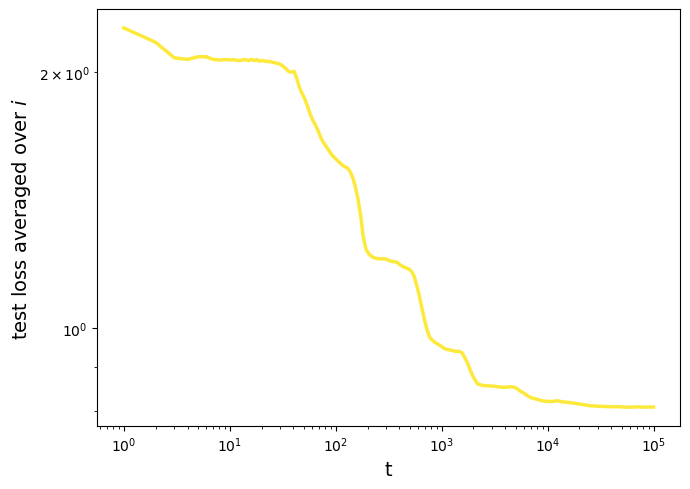

In [9]:
fig, ax = plot_ntp_average_i_all_curves(
    res,
    norm_type="time",
    y_plot="test_loss",
    split="test",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=200,
    avg_min_count=1,
    lw=2.5,
)

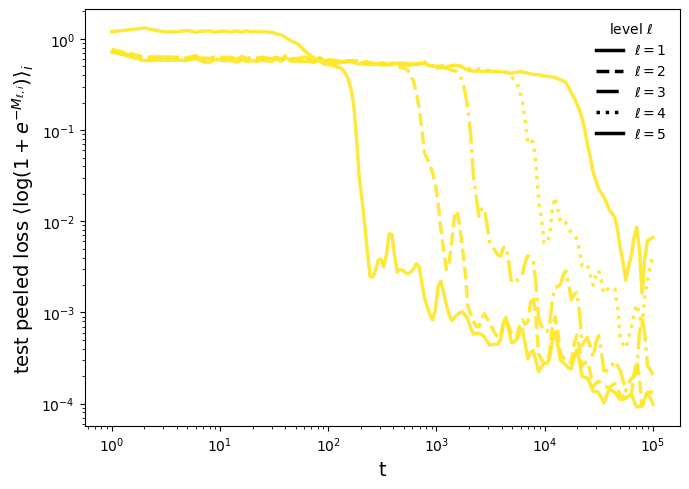

In [10]:
fig, ax = plot_ntp_average_i_all_curves(
    res,
    norm_type="time",
    y_plot="M_l_peeled_loss",
    split="test",
    xscale="log",
    yscale="log",
    average_seeds=True,
    show_seed_std=True,
    lw=2.5,
)

/tmp/ipykernel_19926/1634284846.py:843: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves_arr, axis=0)


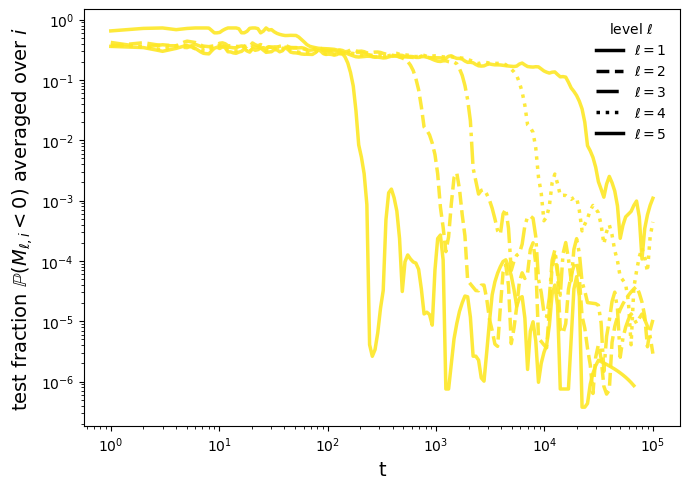

In [11]:
fig, ax = plot_ntp_average_i_all_curves(
    res,
    norm_type="time",
    y_plot="M_l_neg_frac",
    split="test",
    xscale="log",
    yscale="log",
    average_seeds=True,
    show_seed_std=True,
    lw=2.5,
)

## L=4, v2

In [2]:
res = load_collected_results(
    "slm_TR2_uniform_L4_v1",
    collected_results_dir="collected_results",
)

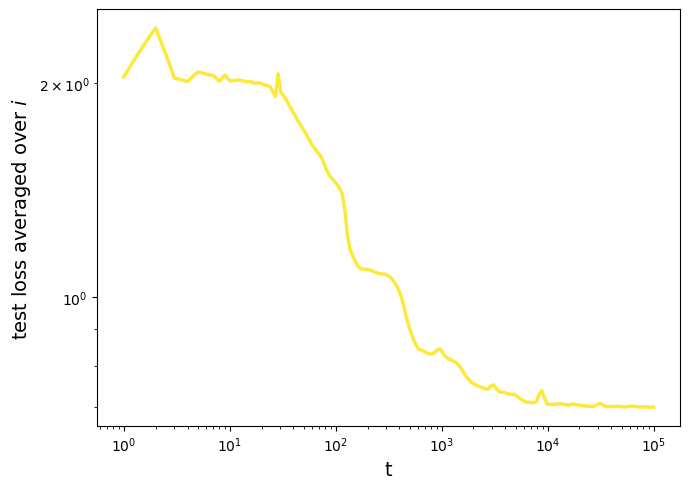

In [3]:
fig, ax = plot_ntp_average_i_all_curves(
    res,
    norm_type="time",
    y_plot="test_loss",
    split="test",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=200,
    avg_min_count=1,
    lw=2.5,
)

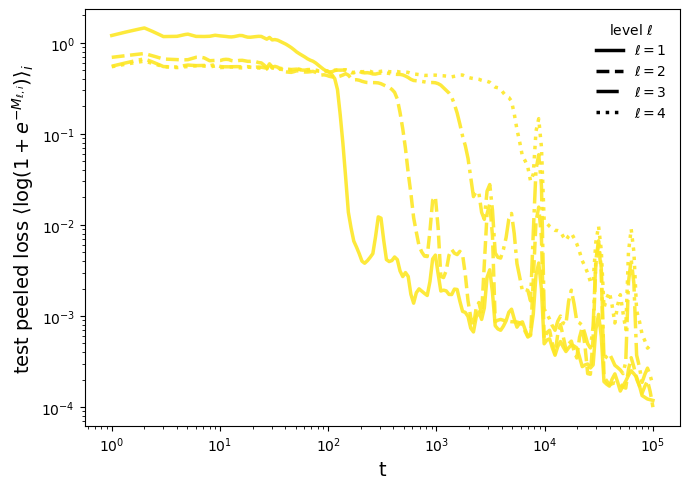

In [5]:
fig, ax = plot_ntp_average_i_all_curves(
    res,
    norm_type="time",
    y_plot="M_l_peeled_loss",
    split="test",
    xscale="log",
    yscale="log",
    average_seeds=True,
    show_seed_std=True,
    lw=2.5,
)

/tmp/ipykernel_19926/1634284846.py:843: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves_arr, axis=0)


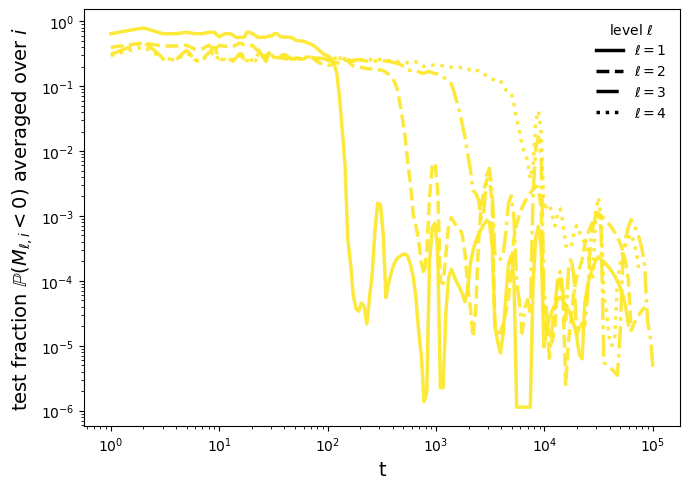

In [7]:
fig, ax = plot_ntp_average_i_all_curves(
    res,
    norm_type="time",
    y_plot="M_l_neg_frac",
    split="test",
    xscale="log",
    yscale="log",
    average_seeds=True,
    show_seed_std=True,
    lw=2.5,
)

## L=3, varius cases

In [2]:
res = load_collected_results(
    "slm_TR2_uniform_L3_v1",
    collected_results_dir="collected_results",
)

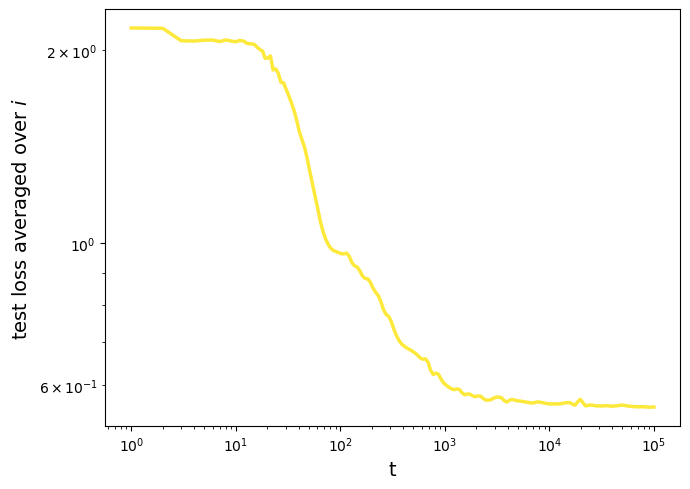

In [3]:
fig, ax = plot_ntp_average_i_all_curves(
    res,
    norm_type="time",
    y_plot="test_loss",
    split="test",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=200,
    avg_min_count=1,
    lw=2.5,
)

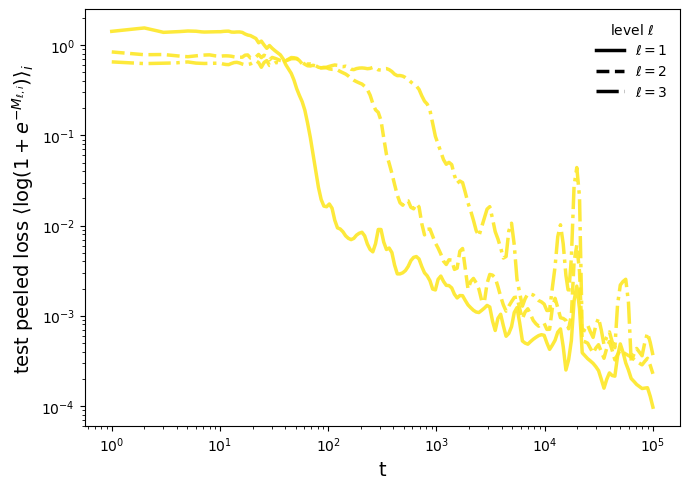

In [4]:
fig, ax = plot_ntp_average_i_all_curves(
    res,
    norm_type="time",
    y_plot="M_l_peeled_loss",
    split="test",
    M_l_levels=[1, 2, 3],
    xscale="log",
    yscale="log",
    average_seeds=True,
    show_seed_std=True,
    lw=2.5,
)

/tmp/ipykernel_7945/1634284846.py:843: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves_arr, axis=0)


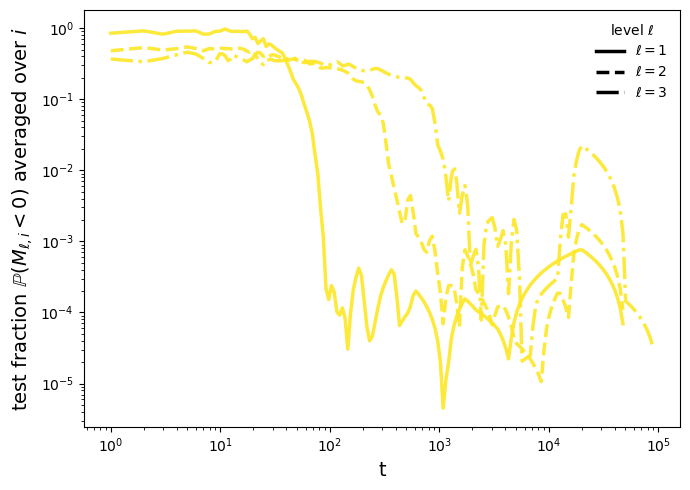

In [5]:
fig, ax = plot_ntp_average_i_all_curves(
    res,
    norm_type="time",
    y_plot="M_l_neg_frac",
    split="test",
    M_l_levels=[1, 2, 3],
    xscale="log",
    yscale="log",
    average_seeds=True,
    show_seed_std=True,
    lw=2.5,
)

In [6]:
res = load_collected_results(
    "slm_uniform_L3_v1",
    collected_results_dir="collected_results",
)

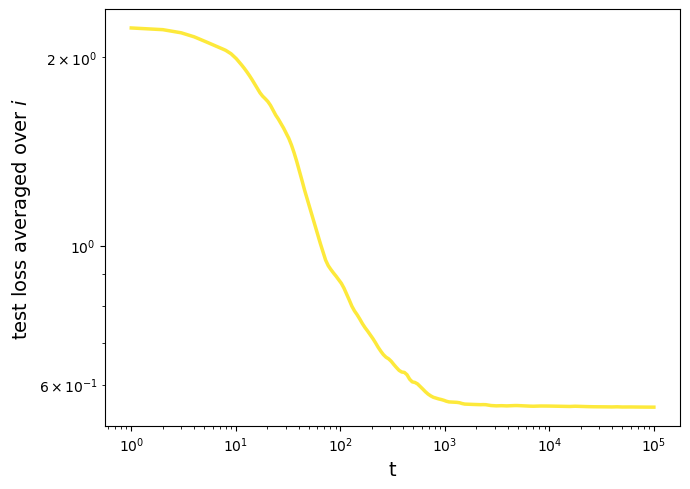

In [7]:
fig, ax = plot_ntp_average_i_all_curves(
    res,
    norm_type="time",
    y_plot="test_loss",
    split="test",
    xscale="log",
    yscale="log",
    average_seeds=True,
    avg_num_x=200,
    avg_min_count=1,
    lw=2.5,
)

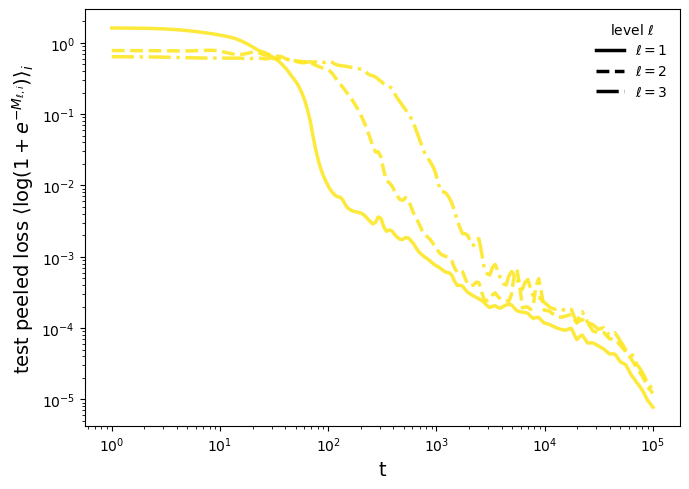

In [8]:
fig, ax = plot_ntp_average_i_all_curves(
    res,
    norm_type="time",
    y_plot="M_l_peeled_loss",
    split="test",
    M_l_levels=[1, 2, 3],
    xscale="log",
    yscale="log",
    average_seeds=True,
    show_seed_std=True,
    lw=2.5,
)

/tmp/ipykernel_13540/2709325975.py:843: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(curves_arr, axis=0)


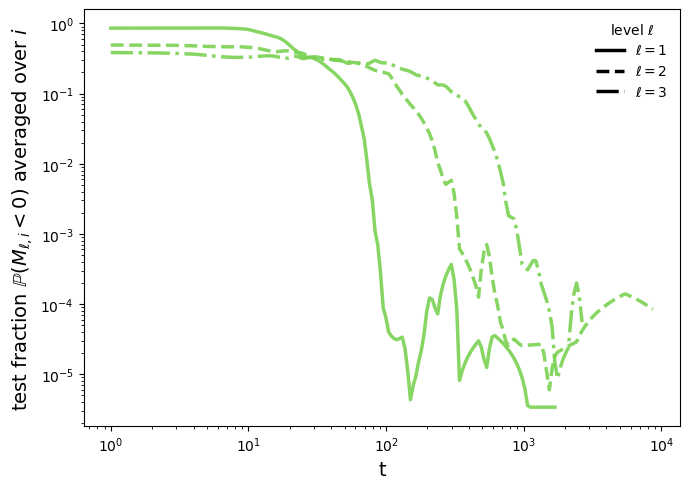

In [10]:
fig, ax = plot_ntp_average_i_all_curves(
    res,
    norm_type="time",
    y_plot="M_l_neg_frac",
    split="test",
    M_l_levels=[1, 2, 3],
    xscale="log",
    yscale="log",
    average_seeds=True,
    show_seed_std=True,
    lw=2.5,
)

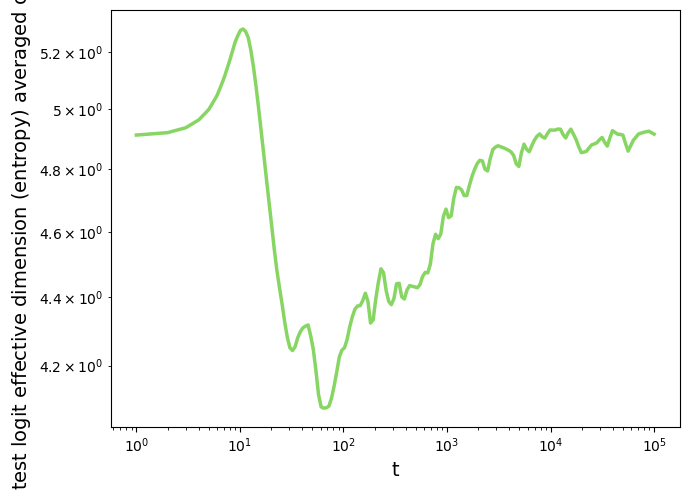

In [13]:
fig, ax = plot_ntp_average_i_all_curves(
    res,
    norm_type="time",
    y_plot="effective_dimension",
    split="test",
    xscale="log",
    yscale="log",
    average_seeds=True,
    show_seed_std=True,
    lw=2.5,
)